## 3. Sélection des variables pour la suite de l'analyse

### 3.1 Variables candidates pour la segmentation

L'objectif de la segmentation est d'identifier des profils homogènes de
collaborateurs à partir de leurs caractéristiques professionnelles et de leurs
conditions de travail.

La variable `Attrition` n'est pas utilisée pour construire les clusters afin
d'éviter de définir artificiellement les groupes à partir de la variable que
l'analyse cherche ensuite à étudier.

Les variables candidates ont été organisées autour de plusieurs dimensions :
profil, carrière, rémunération, expérience au travail et mobilité/charge de
travail.

Les variables fortement redondantes ne sont pas conservées simultanément
lorsqu'elles risquent de surpondérer une même dimension. Ainsi, `JobLevel`
est écarté de la construction initiale des clusters en raison de sa forte
redondance avec `MonthlyIncome`.

Certaines variables catégorielles telles que `JobRole`, `Department` ou
`MaritalStatus` seront principalement utilisées après la segmentation afin
de caractériser et d'interpréter les clusters obtenus.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from scipy.stats import *
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# %matplotlib.inline


In [5]:
server = r"(localdb)\ProjectModels"
database = "Hr_analytics"

connection_string = quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={connection_string}")
query = """
SELECT  *
FROM PROCESSED.employees;
"""

df = pd.read_sql(query, engine)

data = df.copy()


In [6]:
segmentation_features = {
    "profil": ["Age"],
    "carriere": [
        "TotalWorkingYears",
        "YearsAtCompany",
        "YearsInCurrentRole",
        "YearsWithCurrManager",
    ],
    "remuneration": ["MonthlyIncome", "StockOptionLevel"],
    "experience_travail": [
        "JobInvolvement",
        "JobSatisfaction",
        "EnvironmentSatisfaction",
    ],
    "mobilite_charge": ["DistanceFromHome", "OverTime", "BusinessTravel"],
}


cluster_features = [
    feature for features in segmentation_features.values() for feature in features
]

data_cluster = data[cluster_features].copy()

data_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   TotalWorkingYears        1470 non-null   int64 
 2   YearsAtCompany           1470 non-null   int64 
 3   YearsInCurrentRole       1470 non-null   int64 
 4   YearsWithCurrManager     1470 non-null   int64 
 5   MonthlyIncome            1470 non-null   int64 
 6   StockOptionLevel         1470 non-null   int64 
 7   JobInvolvement           1470 non-null   int64 
 8   JobSatisfaction          1470 non-null   int64 
 9   EnvironmentSatisfaction  1470 non-null   int64 
 10  DistanceFromHome         1470 non-null   int64 
 11  OverTime                 1470 non-null   object
 12  BusinessTravel           1470 non-null   object
dtypes: int64(11), object(2)
memory usage: 149.4+ KB


In [7]:
data["OverTime"] = data["OverTime"].map({"Yes": 1, "No": 0})

In [8]:
numeric_features = [
    "Age",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "MonthlyIncome",
    "DistanceFromHome",
]

ordinal_features = [
    "StockOptionLevel",
    "JobInvolvement",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
]

binary_features = ["OverTime"]

categorical_features = ["BusinessTravel"]


In [9]:


preprocessor = ColumnTransformer(
    transformers=[
        # Variables numériques
        ("num", StandardScaler(), numeric_features),
        # Variables ordinales
        ("ord", StandardScaler(), ordinal_features),
        # Variable binaire déjà en 0/1
        ("bin", "passthrough", binary_features),
        # Variable nominale
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)


In [10]:
preprocessing_pipeline = Pipeline(steps=[("preprocessor", preprocessor)])


In [11]:
X_cluster = data[cluster_features].copy()

X_processed = preprocessor.fit_transform(X_cluster)

print("Shape initiale :", X_cluster.shape)
print("Shape après preprocessing :", X_processed.shape)


Shape initiale : (1470, 13)
Shape après preprocessing : (1470, 15)


In [22]:


# k_values = range(2, 11)

# results_k = []

# for k in k_values:
#     model = KMeans(n_clusters=k, random_state=42, n_init="auto")

#     labels = model.fit_predict(X_processed)

#     results_k.append(
#         {
#             "K": k,
#             "Inertia": model.inertia_,
#             "Silhouette": silhouette_score(X_processed, labels),
#         }
#     )

# k_results = pd.DataFrame(results_k)

# k_results


K_values = range(2,10)
results_k = []

for k in K_values:
    model = KMeans(n_clusters = k , max_iter = 500 , random_state = 0 , n_init = 'auto')
    labels = model.fit_predict(X_processed)
    results_k.append(
        {
            "K": k,
            "Inertia": model.inertia_,
            "Silhouette": silhouette_score(X_processed, labels),
        }
    )
k_results = pd.DataFrame(results_k)

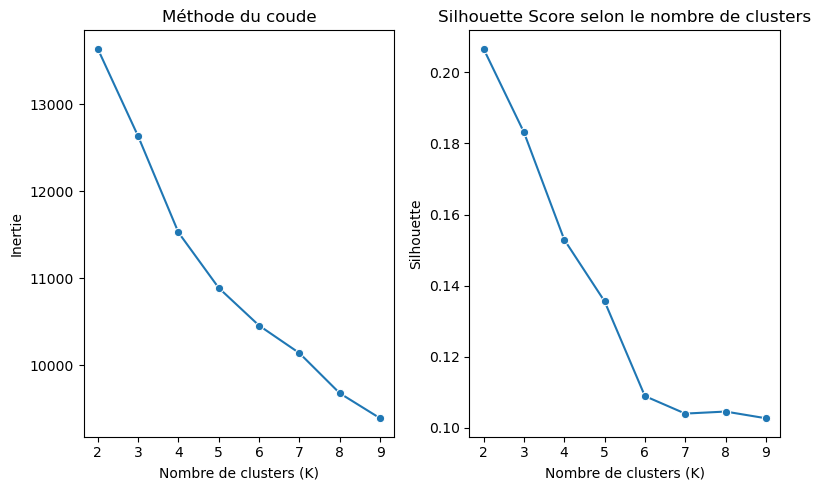

In [23]:
fig , ax = plt.subplots(ncols=2 , figsize=(8,5))
sns.lineplot(data=k_results, x="K", y="Inertia", marker="o" , ax =ax[0])
ax[0].set_title("Méthode du coude")
ax[0].set_xlabel("Nombre de clusters (K)")
ax[0].set_ylabel("Inertie")
ax[0].set_xticks(k_results["K"])

sns.lineplot(data=k_results, x="K", y="Silhouette", marker="o", ax=ax[1])
ax[1].set_title("Silhouette Score selon le nombre de clusters")
ax[1].set_xlabel("Nombre de clusters (K)")
ax[1].set_ylabel("Silhouette")
ax[1].set_xticks(k_results["K"])



plt.tight_layout()
plt.show()


### Choix initial du nombre de clusters

Le nombre de clusters a été évalué pour K compris entre 2 et 10 à l'aide de
l'inertie intra-cluster et du coefficient de silhouette.

La meilleure silhouette est obtenue pour K=2, avec un score d'environ 0,21.
La qualité de séparation reste toutefois relativement faible, indiquant que
les collaborateurs ne présentent pas une structure de groupes naturellement
très marquée dans l'espace de variables considéré.

La méthode du coude ne met pas en évidence de rupture unique et particulièrement
nette. Le choix du nombre final de clusters ne sera donc pas réalisé uniquement
à partir de critères géométriques.

Les solutions K=2 à K=5 seront comparées en fonction de la taille des groupes,
de leurs profils moyens et de leur interprétabilité métier .

In [24]:
label =KMeans(random_state = 0 , n_init='auto' , n_clusters=3).fit_predict(X_processed)
counts = pd.Series(label).value_counts().sort_index()
counts.items


<bound method Series.items of 0    167
1    840
2    463
Name: count, dtype: int64>

In [65]:
candidats_k = range(2, 5)
results = []
for k in candidats_k:
    model = KMeans( n_clusters=k, n_init="auto" , random_state = 42)
    label = model.fit_predict(X_processed)
    counts = pd.Series(label).value_counts().sort_index()
    for id, val in counts.items():
        results.append(
            {"K": k, "Cluster": id, "Effectifs": round(val / len(label) * 100, 2)}
        )

pd.DataFrame(results)


,K,Cluster,Effectifs
0,2,0,64.42
1,2,1,35.58
2,3,0,57.48
3,3,1,14.69
4,3,2,27.82
5,4,0,23.74
6,4,1,14.42
7,4,2,25.65
8,4,3,36.19


* Pour k = [2,3,4,5] les effectifs dans chaque cluster est raisonnable , nous n'avons pas de cluster avec de petite effectif

In [66]:
# feature_names = preprocessing_pipeline.named_steps[
#     "preprocessor"
# ].get_feature_names_out()

# X_cluster_processed = pd.DataFrame(
#     X_cluster_processed, columns=feature_names, index=X_cluster.index
# )

# X_cluster_processed.head()


In [67]:
def profile_clusters(X_original, labels, k):
    profile = X_original.copy()
    profile["Cluster"] = labels

    numeric_profile = profile.groupby("Cluster").mean(numeric_only=True).round(2)

    numeric_profile.insert(0, "K", k)

    return numeric_profile


In [68]:
candidate_models = {}
candidate_labels = {}
candidate_profiles = {}

for k in [2, 3, 4, 5 ]:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")

    labels = model.fit_predict(X_processed)

    candidate_models[k] = model
    candidate_labels[k] = labels

    candidate_profiles[k] = profile_clusters(X_cluster, labels, k)


In [69]:
candidate_profiles[4]

,K,Age,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,MonthlyIncome,StockOptionLevel,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,DistanceFromHome,OverTime
Cluster,,,,,,,,,,,,,
0,4,34.29,7.51,3.61,2.03,2.12,4387.86,0.74,2.74,1.47,2.72,9.07,0.28
1,4,48.42,25.98,14.94,7.03,6.76,15499.22,0.77,2.68,2.67,2.75,8.46,0.29
2,4,36.26,12.12,10.48,7.77,7.61,6329.32,0.91,2.79,2.84,2.75,9.66,0.25
3,4,34.55,7.30,3.62,2.04,1.91,4428.49,0.76,2.70,3.50,2.69,9.23,0.30


In [70]:
candidate_profiles[3]

,K,Age,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,MonthlyIncome,StockOptionLevel,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,DistanceFromHome,OverTime
Cluster,,,,,,,,,,,,,
0,3,34.30,7.20,3.44,1.94,1.88,4313.75,0.76,2.71,2.72,2.69,9.09,0.30
1,3,48.35,25.89,14.70,6.92,6.65,15508.58,0.76,2.68,2.66,2.76,8.56,0.28
2,3,36.31,11.98,10.31,7.54,7.43,6269.76,0.89,2.79,2.79,2.76,9.74,0.25


In [71]:
profile_k3 = X_cluster.copy()
profile_k3["Cluster"] = candidate_labels[3]


In [72]:
business_travel_profile = (
    pd.crosstab(profile_k3["Cluster"], profile_k3["BusinessTravel"], normalize="index")
    .mul(100)
    .round(2)
)

business_travel_profile


BusinessTravel,Non-Travel,Travel_Frequently,Travel_Rarely
Cluster,,,
0,9.23,18.70,72.07
1,6.94,19.44,73.61
2,13.94,18.83,67.24


### Choix final du nombre de clusters

La solution à trois clusters (`K = 3`) est retenue comme compromis entre
qualité de séparation, parcimonie et interprétabilité métier.

Parmi les solutions étudiées, `K = 2` présente le meilleur coefficient de
silhouette (~0,21). Cette solution reste cependant relativement générale :
elle distingue principalement les collaborateurs selon leur stade de carrière
et ne permet pas d'identifier suffisamment de profils différenciés pour
répondre à l'objectif de segmentation RH.

La solution `K = 3` présente un coefficient de silhouette d'environ **0,15**,
inférieur à celui de `K = 2` mais supérieur à celui obtenu avec `K = 4`
(~0,10). Elle fait apparaître trois profils métier interprétables, principalement
structurés par l'expérience professionnelle, l'ancienneté dans l'entreprise
et le niveau de rémunération :

- un groupe de collaborateurs en **début de carrière** ;
- un groupe de collaborateurs **expérimentés avec une forte ancienneté interne** ;
- un groupe de **seniors disposant d'une forte expérience professionnelle**.

Les trois segments représentent respectivement environ **57,5 %**, **27,8 %**
et **14,7 %** de la population. Aucun micro-cluster n'est donc observé.

L'étude de la solution `K = 4` montre qu'elle conserve globalement les profils
« expérimentés » et « seniors », mais subdivise principalement le groupe des
collaborateurs en début de carrière selon leur niveau de satisfaction
professionnelle. Cette granularité supplémentaire apporte un intérêt descriptif,
mais s'accompagne d'une diminution de la qualité de séparation des clusters.

La satisfaction professionnelle reste néanmoins une dimension importante de
l'analyse RH. Elle sera étudiée comme caractéristique permettant de différencier
les collaborateurs au sein des segments, plutôt que comme critère justifiant
à elle seule la création d'un cluster supplémentaire.

Les variables `OverTime` et `BusinessTravel`, bien qu'associées à l'attrition
dans l'analyse statistique univariée, présentent par ailleurs des distributions
relativement proches entre les différents segments. Elles ne constituent donc
pas les principaux axes structurant la segmentation obtenue.

Enfin, le coefficient de silhouette de `K = 3` reste relativement faible
(~0,15). Les données ne présentent donc pas une structure de groupes naturellement
et fortement séparés. Les clusters doivent être interprétés comme des
**profils RH exploratoires et synthétiques**, utiles pour le profiling et la
visualisation des collaborateurs, et non comme des populations parfaitement
distinctes.

Le choix final de `K = 3` repose ainsi sur un compromis entre **qualité
géométrique, simplicité du modèle et pertinence métier**, plutôt que sur
l'optimisation d'un unique indicateur statistique.

In [73]:
data_segmented = data.copy()

data_segmented["Cluster"] = candidate_labels[3]


In [74]:
data["Attrition_flag"] = data["Attrition"].map({"Yes": 1, "No": 0})

cluster_attrition = (
    data_segmented.groupby("Cluster")
    .agg(
        Employees=("Attrition_flag", "size"),
        EmployeesLeft=("Attrition_flag", "sum"),
        AttritionRate=("Attrition_flag", "mean"),
    )
    .reset_index()
)

cluster_attrition["AttritionRate"] *= 100

cluster_attrition.round(2)


,Cluster,Employees,EmployeesLeft,AttritionRate
0,0,845,177,20.95
1,1,216,14,6.48
2,2,409,46,11.25


### Les profils obtenus avec K = 3

La segmentation retenue fait apparaître trois profils principalement
différenciés par leur trajectoire professionnelle, leur ancienneté et leur
niveau de rémunération.

**Cluster 0 — Début de carrière**

Ce segment regroupe 845 collaborateurs (57,5 % de la population). Il se
caractérise par une expérience professionnelle plus faible (7,2 ans en
moyenne), une ancienneté limitée dans l'entreprise (3,4 ans) et une durée
relativement courte dans le poste actuel et auprès du manager actuel
(environ 2 ans). Le revenu mensuel moyen est également le plus faible
des trois segments (4 314).

Ce segment présente rétrospectivement le taux d'attrition le plus élevé
des trois profils : 20,95 %.

**Cluster 1 — Seniors · forte expérience**

Ce segment rassemble 216 collaborateurs (14,7 %). Il correspond aux
profils les plus expérimentés, avec un âge moyen de 48,4 ans, près de
25,9 années d'expérience professionnelle et 14,7 années d'ancienneté
dans l'entreprise. Il présente également le revenu mensuel moyen le plus
élevé (15 509).

Son taux d'attrition observé est le plus faible des trois segments :
6,48 %.

**Cluster 2 — Expérimentés · forte ancienneté interne**

Ce segment comprend 409 collaborateurs (27,8 %). Il se distingue
principalement par une forte stabilité au sein de l'entreprise :
10,3 années d'ancienneté en moyenne, 7,5 années dans le rôle actuel et
7,4 années avec le manager actuel.

Son taux d'attrition observé atteint 11,25 %, soit un niveau intermédiaire
entre les deux autres segments.

Les variables liées à la satisfaction, à la distance domicile-travail
et aux heures supplémentaires présentent des moyennes relativement
proches entre les trois groupes. La segmentation semble donc être
principalement structurée par les dimensions de carrière, d'ancienneté
et de rémunération.

Les taux d'attrition sont utilisés uniquement pour caractériser les
segments après leur construction. La variable cible `Attrition` n'a pas
été utilisée par l'algorithme K-Means pour former les clusters.

In [75]:
cluster_names= {
    0: "Début de carrière",
    1: "Seniors - forte expérience",
    2: "Expérimentés - forte ancienneté",
}
data_segmented["Segment"] = data_segmented["Cluster"].map(cluster_names)


### Segmentation retenue et attrition observée

Une segmentation K-Means à trois groupes (`K = 3`) a été retenue après
comparaison de plusieurs solutions sur la base du coefficient de silhouette,
de l'inertie, de la taille des groupes et de leur interprétabilité métier.

Bien que `K = 2` présente le meilleur coefficient de silhouette (~0,21),
la solution `K = 3` offre un compromis plus pertinent pour l'objectif de
profiling RH. Elle conserve une meilleure qualité de séparation que `K = 4`
(~0,15 contre ~0,10), tout en faisant apparaître trois profils professionnels
distincts et interprétables.

La variable `Attrition` n'a pas été utilisée lors de la construction des
clusters. Elle a été réintroduite uniquement après la segmentation afin
d'étudier rétrospectivement la fréquence des départs dans chaque profil.

Les trois segments obtenus présentent les taux d'attrition suivants :

- **Cluster 0 — Début de carrière** :
  **20,95 %** (177 départs sur 845 collaborateurs) ;
- **Cluster 1 — Seniors · forte expérience** :
  **6,48 %** (14 départs sur 216 collaborateurs) ;
- **Cluster 2 — Expérimentés · forte ancienneté interne** :
  **11,25 %** (46 départs sur 409 collaborateurs).

À titre de comparaison, le taux d'attrition global de la population est
de **16,12 %**.

Le **cluster 0** représente 57,5 % des collaborateurs et présente le taux
d'attrition observé le plus élevé (20,95 %). Il regroupe principalement des
collaborateurs situés dans une phase moins avancée de leur trajectoire
professionnelle : 34,3 ans en moyenne, 7,2 années d'expérience professionnelle,
3,4 années d'ancienneté dans l'entreprise et environ 2 années dans leur rôle
actuel. Leur revenu mensuel moyen est également le plus faible des trois
segments (4 314).

Le **cluster 2**, représentant 27,8 % de la population, correspond à des
collaborateurs expérimentés bénéficiant d'une forte ancienneté interne.
Ils comptent en moyenne 12 années d'expérience professionnelle, 10,3 années
dans l'entreprise, 7,5 années dans leur rôle actuel et 7,4 années avec leur
manager actuel. Leur taux d'attrition observé est intermédiaire, à **11,25 %**.

Le **cluster 1**, qui représente 14,7 % des collaborateurs, rassemble les
profils les plus expérimentés : 48,4 ans en moyenne, 25,9 années d'expérience
professionnelle et 14,7 années d'ancienneté dans l'entreprise. Il présente
également le revenu mensuel moyen le plus élevé (15 509) et le taux
d'attrition observé le plus faible, à **6,48 %**.

Contrairement à la solution `K = 4`, les niveaux moyens de satisfaction
professionnelle sont relativement proches entre les trois segments
(2,72 ; 2,66 ; 2,79). Les proportions de collaborateurs effectuant des
heures supplémentaires sont également comparables (30 % ; 28 % ; 25 %).

La segmentation `K = 3` semble ainsi être principalement structurée par
des dimensions liées à la **trajectoire professionnelle, l'expérience,
l'ancienneté interne et la rémunération**, plutôt que par les dimensions
de satisfaction ou de charge de travail.



In [76]:
profile_categorical_features = [
    "JobRole",
    "Department",
    "MaritalStatus",
    "EducationField",
    "Gender",
    "BusinessTravel",
    "OverTime"
]

In [77]:
def categorical_cluster_profile(data, cluster_col, feature):
    profile = pd.crosstab(data[cluster_col], data[feature], normalize="index")

    return (profile * 100).round(2)


In [78]:
categorical_profiles = {}

for feature in profile_categorical_features:
    categorical_profiles[feature] = categorical_cluster_profile(
        data_segmented, "Cluster", feature
    )


categorical_profiles

{'JobRole': JobRole  Healthcare Representative  Human Resources  Laboratory Technician  \
 Cluster                                                                      
 0                             7.34             4.62                  23.20   
 1                            11.57             0.93                   0.93   
 2                            10.76             2.69                  14.91   
 
 JobRole  Manager  Manufacturing Director  Research Director  \
 Cluster                                                       
 0           0.59                    7.46               1.18   
 1          41.67                    9.26              24.54   
 2           1.71                   15.16               4.16   
 
 JobRole  Research Scientist  Sales Executive  Sales Representative  
 Cluster                                                             
 0                     26.98            19.64                  8.99  
 1                      0.00            11.11               

In [79]:
def representation_index(data, cluster_col, feature):
    cluster_distribution = pd.crosstab(
        data[cluster_col], data[feature], normalize="index"
    )

    global_distribution = data[feature].value_counts(normalize=True)

    representation = cluster_distribution.div(global_distribution, axis=1)

    return representation.round(2)


In [80]:
representation_profiles = {}

for feature in profile_categorical_features:
    representation_profiles[feature] = representation_index(
        data_segmented, "Cluster", feature
    )


In [81]:
representation_profiles


{'JobRole': JobRole  Healthcare Representative  Human Resources  Laboratory Technician  \
 Cluster                                                                      
 0                             0.82             1.30                   1.32   
 1                             1.30             0.26                   0.05   
 2                             1.21             0.76                   0.85   
 
 JobRole  Manager  Manufacturing Director  Research Director  \
 Cluster                                                       
 0           0.09                    0.76               0.22   
 1           6.00                    0.94               4.51   
 2           0.25                    1.54               0.76   
 
 JobRole  Research Scientist  Sales Executive  Sales Representative  
 Cluster                                                             
 0                      1.36             0.89                  1.59  
 1                      0.00             0.50               

In [82]:
cluster_names = {
    0: "Début de carrière - faible satisfaction",
    1: "Seniors - postes à responsabilité",
    2: "Expérimentés - forte ancienneté interne",
    3: "Début de carrière - forte satisfaction",
}

data_segmented["Segment"] = data_segmented["Cluster"].map(cluster_names)


In [83]:
(
    data_segmented.groupby("Segment")
    .agg(
        Effectif=("EmployeeNumber", "count"),
        Departs=("Attrition_flag", "sum"),
        TauxAttrition=("Attrition_flag", "mean"),
    )
    .assign(TauxAttrition=lambda x: x["TauxAttrition"] * 100)
    .round(2)
)


,Effectif,Departs,TauxAttrition
Segment,,,
Début de carrière - faible satisfaction,845,177,20.95
Expérimentés - forte ancienneté interne,409,46,11.25
Seniors - postes à responsabilité,216,14,6.48


In [84]:
from sklearn.metrics import silhouette_samples

# Labels de la solution K=4
labels = candidate_labels[3]

# Silhouette individuelle de chaque employé
silhouette_values = silhouette_samples(X_processed, labels)

# Table de contrôle
silhouette_data = pd.DataFrame({"Cluster": labels, "Silhouette": silhouette_values})

# Résumé par cluster
silhouette_by_cluster = (
    silhouette_data.groupby("Cluster")
    .agg(
        Effectif=("Silhouette", "size"),
        SilhouetteMoyenne=("Silhouette", "mean"),
        SilhouetteMediane=("Silhouette", "median"),
        SilhouetteMin=("Silhouette", "min"),
        SilhouetteMax=("Silhouette", "max"),
        PartNegative=("Silhouette", lambda x: (x < 0).mean() * 100),
    )
    .round(3)
)

silhouette_by_cluster


,Effectif,SilhouetteMoyenne,SilhouetteMediane,SilhouetteMin,SilhouetteMax,PartNegative
Cluster,,,,,,
0,845,0.175,0.181,0.011,0.337,0.000
1,216,0.088,0.097,-0.077,0.244,18.519
2,409,0.139,0.142,-0.008,0.312,1.711


### Validation interne de la segmentation retenue

La solution `K = 3` présente un coefficient de silhouette global d'environ
**0,153**. Cette valeur reste modeste et indique que la structure naturelle
des données n'est pas fortement segmentée.

L'analyse de la silhouette par cluster apporte néanmoins des informations
complémentaires sur la cohérence interne des trois profils.

Le **cluster 0 — Début de carrière** présente la meilleure cohérence interne,
avec une silhouette moyenne de **0,175** et aucune observation présentant
une silhouette négative. Les collaborateurs affectés à ce segment sont donc
globalement plus proches de leur propre cluster que des autres groupes.

Le **cluster 2 — Expérimentés · forte ancienneté interne** présente une
silhouette moyenne de **0,139**. Seulement **1,71 %** de ses observations
possèdent une silhouette négative, ce qui indique une affectation globalement
cohérente malgré une séparation modérée.

Le **cluster 1 — Seniors · forte expérience** constitue le groupe le moins
nettement séparé. Sa silhouette moyenne atteint **0,088** et environ
**18,52 %** de ses observations présentent une silhouette négative. Une
partie des collaborateurs de ce segment se situe donc à la frontière avec
un autre profil, notamment avec les collaborateurs expérimentés.

Ces résultats confirment que les clusters ne doivent pas être interprétés
comme des populations parfaitement distinctes. La segmentation est utilisée
comme un outil exploratoire permettant de synthétiser plusieurs dimensions
RH en trois grands profils interprétables.

Malgré cette séparation modérée, `K = 3` est conservé car il offre un meilleur
compromis entre qualité géométrique, parcimonie et interprétabilité métier
que la solution `K = 4`, tout en fournissant une segmentation plus informative
pour l'analyse RH que la solution plus générale à deux clusters.

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

segmentation_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("kmeans", KMeans(n_clusters=3, random_state=42, n_init="auto")),
    ]
)

segmentation_pipeline.fit(data[cluster_features])


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'TotalWorkingYears',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsWithCurrManager',
                                                   'MonthlyIncome',
                                                   'DistanceFromHome']),
                                                 ('ord', StandardScaler(),
                                                  ['StockOptionLevel',
                                                   'JobInvolvement',
                                                   'JobSatisfaction',
                                                   'EnvironmentSatisfaction']),
                                                 ('bin', 'passthrough',
                                                  ['OverTime']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['BusinessTravel'])],
                                   verbose_feature_names_out=False)),
                ('kmeans', KMeans(n_clusters=3, random_state=42))])

In [86]:
final_labels = segmentation_pipeline.predict(data[cluster_features])

# pd.crosstab(
#     candidate_labels[3],
#     final_labels,
#     rownames=["Ancien cluster"],
#     colnames=["Pipeline final"],
# )


In [87]:
cluster_names = {
    0: "Début de carrière",
    1: "Seniors - forte expérience",
    2: "Expérimentés - forte ancienneté",
}

data_segmented = data.copy()

data_segmented["Cluster"] = final_labels
data_segmented["Segment"] = data_segmented["Cluster"].map(cluster_names)


In [88]:
import joblib
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)

joblib.dump(segmentation_pipeline, "../models/employee_segmentation.joblib")


['../models/employee_segmentation.joblib']

In [89]:
Path("../outputs").mkdir(parents=True, exist_ok=True)

segment_export = data_segmented[["EmployeeNumber", "Cluster", "Segment"]].copy()

segment_export.to_csv(
    "../outputs/employee_segments.csv", index=False, encoding="utf-8-sig"
)

# segment_export.head()


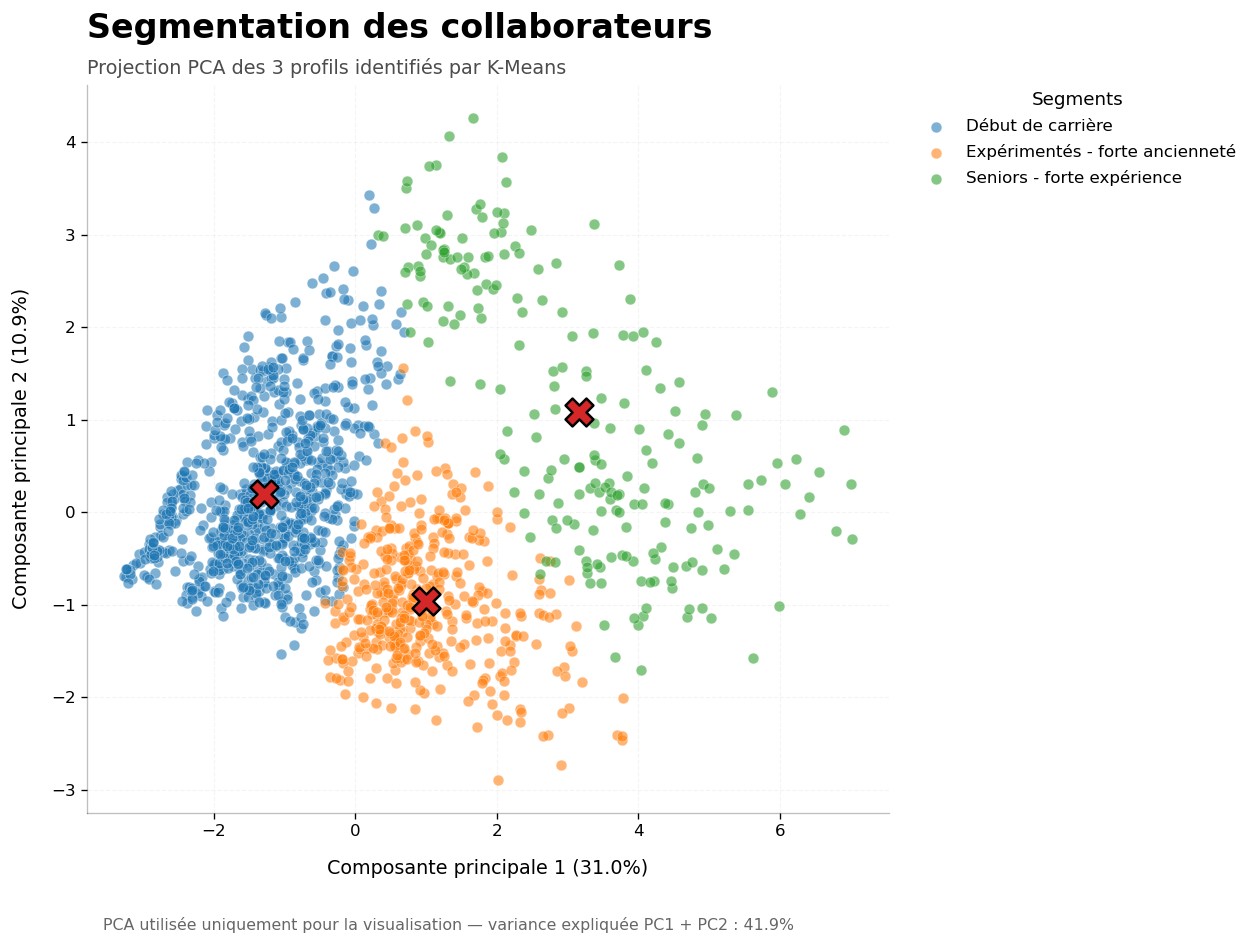

In [ ]:
# ============================================================
# VISUALISATION PCA DES CLUSTERS K-MEANS
# Version finale PowerPoint / Portfolio
# ============================================================



# ------------------------------------------------------------
# 1. PCA 2D
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

variance_pc1 = pca.explained_variance_ratio_[0]
variance_pc2 = pca.explained_variance_ratio_[1]
variance_total = pca.explained_variance_ratio_.sum()


# ------------------------------------------------------------
# 2. DataFrame de visualisation
# ------------------------------------------------------------

pca_data = pd.DataFrame(
    {"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "Cluster": candidate_labels[3]}
)


# ------------------------------------------------------------
# 3. Noms métier des clusters
# ------------------------------------------------------------


pca_data["Segment"] = pca_data["Cluster"].map(cluster_names)


# ------------------------------------------------------------
# 4. Centroïdes K-Means
# ------------------------------------------------------------

centroids = candidate_models[3].cluster_centers_

centroids_pca = pca.transform(centroids)


# ------------------------------------------------------------
# 5. Création du graphique
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 8), dpi=120)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")


# ------------------------------------------------------------
# 6. Scatter plot par segment
# ------------------------------------------------------------

for segment, group in pca_data.groupby("Segment"):
    ax.scatter(
        group["PC1"],
        group["PC2"],
        s=42,
        alpha=0.58,
        edgecolors="white",
        linewidths=0.35,
        label=segment,
        zorder=3,
    )


# ------------------------------------------------------------
# 7. Centroïdes
# ------------------------------------------------------------

ax.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=280,
    edgecolor="black",
    linewidth=1.5,
    zorder=10,
)


# ------------------------------------------------------------
# 8. Labels des centroïdes
# ------------------------------------------------------------

# Décalages personnalisés pour éviter le chevauchement
# centroid_offsets = {0: (14, 12), 1: (14, 8), 2: (14, 8), 3: (14, -18)}

# for cluster_id, (x, y) in enumerate(centroids_pca):
#     dx, dy = centroid_offsets[cluster_id]

#     ax.annotate(
#         f"C{cluster_id}",
#         xy=(x, y),
#         xytext=(dx, dy),
#         textcoords="offset points",
#         fontsize=10,
#         fontweight="bold",
#         zorder=11,
#     )


# ------------------------------------------------------------
# 9. Titre principal
# ------------------------------------------------------------

ax.set_title(
    "Segmentation des collaborateurs",
    loc="left",
    fontsize=20,
    fontweight="bold",
    pad=28,
)


# ------------------------------------------------------------
# 10. Sous-titre
# ------------------------------------------------------------

ax.text(
    0,
    1.015,
    "Projection PCA des 3 profils identifiés par K-Means",
    transform=ax.transAxes,
    fontsize=11.5,
    alpha=0.70,
)


# ------------------------------------------------------------
# 11. Labels des axes
# ------------------------------------------------------------

ax.set_xlabel(
    f"Composante principale 1 ({variance_pc1:.1%})", fontsize=11.5, labelpad=12
)

ax.set_ylabel(
    f"Composante principale 2 ({variance_pc2:.1%})", fontsize=11.5, labelpad=12
)


# ------------------------------------------------------------
# 12. Grille légère
# ------------------------------------------------------------

ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.13)

ax.set_axisbelow(True)


# ------------------------------------------------------------
# 13. Suppression des bordures inutiles
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_alpha(0.25)
ax.spines["bottom"].set_alpha(0.25)


# ------------------------------------------------------------
# 14. Style des ticks
# ------------------------------------------------------------

ax.tick_params(axis="both", labelsize=10)


# ------------------------------------------------------------
# 15. Légende
# ------------------------------------------------------------

legend = ax.legend(
    title="Segments",
    frameon=False,
    fontsize=10,
    title_fontsize=11,
    bbox_to_anchor=(1.03, 1),
    loc="upper left",
    borderaxespad=0,
    labelspacing=0.6,
    handletextpad=0.8,
)

legend.get_title().set_fontweight("medium")


# ------------------------------------------------------------
# 16. Note méthodologique
# ------------------------------------------------------------

fig.text(
    0.07,
    0.025,
    (
        "PCA utilisée uniquement pour la visualisation — "
        f"variance expliquée PC1 + PC2 : {variance_total:.1%}"
    ),
    fontsize=9.5,
    alpha=0.60,
)


# ------------------------------------------------------------
# 17. Ajustement des marges
# ------------------------------------------------------------

plt.tight_layout(rect=[0, 0.06, 0.82, 1])


# ------------------------------------------------------------
# 18. Export PowerPoint
# ------------------------------------------------------------

plt.savefig(
    "../outputs/kmeans_clusters_pca_powerpoint.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


# ------------------------------------------------------------
# 19. Affichage
# ------------------------------------------------------------

plt.show()


In [93]:
fig.savefig(
    "../outputs/kmeans_clusters_pca.png", dpi=300, bbox_inches="tight", transparent=True
)


In [94]:
data.to_csv("/data/processed/data.csv")

OSError: Cannot save file into a non-existent directory: '\data\processed'